## What is Equation Discovery?

In many scientific problems, we observe time-series data but do not know the governing equations.

**Equation discovery** aims to recover the underlying dynamical system directly from data.

## Sparse Identification of Nonlinear Dynamics (SINDy)

SINDy assumes that the dynamics can be written as:

$\frac{dx}{dt} = f(x)$

where $f(x)$ is composed of a small number of candidate functions.

The key idea:
- build a large library of possible terms (polynomials, interactions, etc.)
- use sparse regression to select only the important ones

This leads to:
- interpretable models
- compact equations
- insight into system dynamics


## Example: Equation Discovery for an NPZ System

We apply SINDy to recover the governing equations of a simple marine ecosystem model from data.

The system includes:
- N: nitrate
- P: phytoplankton
- Z: zooplankton

All variables are expressed in consistent units.

### Goal

Given time-series data of (N, P, Z), we aim to:
- identify the underlying dynamical system
- recover key interaction terms (e.g., uptake, grazing)
- obtain a sparse, interpretable model

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pysindy as ps
import pandas as pd

We use:
- `pysindy` for sparse equation discovery  
- `numpy` and `pandas` for data handling  
- `matplotlib` for visualization  

### Setup and parameters

We generate synthetic data from a known NPZ (nutrient–phytoplankton–zooplankton) model.

These parameters define the underlying dynamics that SINDy will attempt to recover.

In [2]:
# Franks NPZ model parameters
parameters = {
    'Vm':    2.0,   # maximum growth rate (day-1)
    'ks':    1.0,   # half-saturation constant (ugN/L)
    'm':     0.1,   # mortality rate (day-1)
    'gamma': 0.3,   # unassimilated grazing fraction
    'Rm':    1.5,   # max grazing rate (day-1)
    'ivlev': 1.0,   # Ivlev constant (ugN/L)
    'q':     0.2,   # Z mortality (day-1)
}

seed = 1234

### ODE and integrator

We define the NPZ system as a set of ordinary differential equations.

This represents the *true* dynamics used to generate data.
In practice, SINDy will not have access to these equations and must infer them from observations.

In [3]:
def npz_nl(x, t, p):
    x = np.asarray(x)
    dx = np.zeros_like(x)
    uptake_term  = ((p['Vm'] * x[0]) / (p['ks'] + x[0])) * x[1]
    grazing_term = (p['ivlev'] * x[1] * p['Rm'] * (1 - np.exp(-p['ivlev'] * x[1])) * x[2])

    dx[0] = -uptake_term + (p['m'] * x[1]) + (p['q'] * x[2]) + p['gamma'] * grazing_term
    dx[1] =  uptake_term - (p['m'] * x[1]) - grazing_term
    dx[2] = (1 - p['gamma']) * grazing_term - (p['q'] * x[2])

    return dx

def rk4(f, x0, times, parameters, tfrc=None, frc=None):
    nt = len(times)
    x = np.zeros((nt, len(x0)))
    x[0, :] = x0
    dt = np.zeros(nt)
    dt[1:] = np.diff(times)
    for n in range(1, nt):
        k1 = f(x[n - 1, :], times[n], p=parameters) * dt[n]
        k2 = f(x[n - 1, :] + 0.5 * k1, times[n] + 0.5 * dt[n], p=parameters) * dt[n]
        k3 = f(x[n - 1, :] + 0.5 * k2, times[n] + 0.5 * dt[n], p=parameters) * dt[n]
        k4 = f(x[n - 1, :] + k3, times[n] + dt[n], p=parameters) * dt[n]
        x[n, :] = x[n - 1, :] + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        if tfrc is not None:
            fl = np.where(np.logical_and(tfrc >= times[n] - 0.5 * dt[n],
                                         tfrc < times[n] + 0.5 * dt[n]))[0]
            x[n, :] += f[fl, :].sum(axis=0)
    return x
    

### Generate data

We simulate the NPZ system to generate synthetic time-series data.

This represents the observations that SINDy will use to recover the underlying dynamics.

In [4]:
np.random.seed(seed)

N0, P0, Z0 = 1.6, 0.3, 0.1
x0 = np.array([N0, P0, Z0])
T  = 30.0
dt = 0.1

t_full = np.arange(0, T, dt)
state  = rk4(npz_nl, x0, t_full, parameters)

# Build dataframe for SINDy
data = pd.DataFrame(state, columns=['N', 'P', 'Z'], index=t_full)
data.index.name = 'time'
data

,N,P,Z
time,,,
0.0,1.600000,0.300000,0.100000
0.1,1.566695,0.334394,0.098910
0.2,1.529765,0.372208,0.098027
0.3,1.488976,0.413643,0.097382
0.4,1.444115,0.458875,0.097011
...,...,...,...
29.5,0.514041,0.490961,0.994998
29.6,0.514041,0.490961,0.994998
29.7,0.514041,0.490961,0.994998


### Exploratory data analysis (EDA)

We begin by visualizing the time-series to understand the system dynamics and interactions between variables.

### Time-series

Text(0.5, 1.0, 'NPZ time-series')

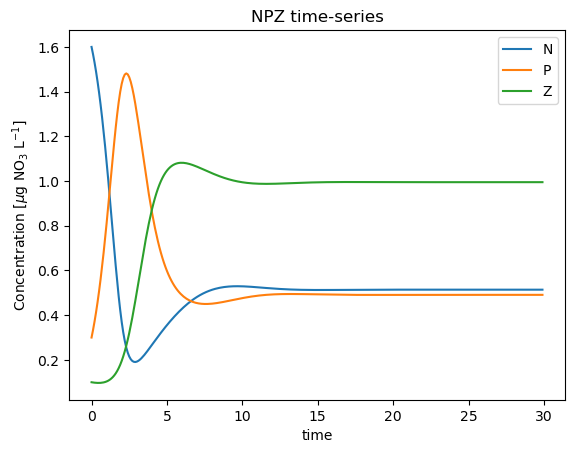

In [5]:
ax = data.plot()
ax.set_ylabel(r"Concentration [$\mu$g NO$_3$ L$^{-1}$]")
ax.set_title("NPZ time-series")

### State-Space

We visualize the trajectory in state-space to examine the dynamical structure of the system.

Text(0.5, 0.92, 'NPZ state-space trajectory')

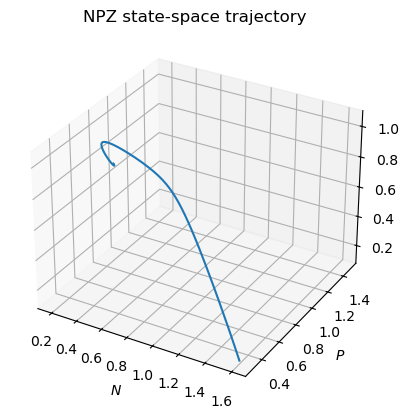

In [6]:
ax = plt.figure().add_subplot(projection='3d')
ax.plot(data['N'], data['P'], data['Z'])
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'$P$')
ax.set_zlabel(r'$Z$')
ax.set_title("NPZ state-space trajectory")

### Training data

We split the time-series into training, validation, and test sets.

For dynamical systems, the split must preserve temporal structure (i.e., no random sampling), since SINDy relies on time derivatives.

In [7]:
# Split by time (not randomly)
train_end = int(np.where(data.index == 17)[0][0])
train_interval = 5

train = data.iloc[:train_end:train_interval]
validate = data.iloc[train_interval//2:train_end:train_interval]
test = data.iloc[train_end::train_interval//2]

The training set is used to fit the model, while validation and test sets assess generalization.

### Train SINDy

We now fit a SINDy model to the training data.

The discovered equations depend on:
- the candidate function library
- the sparsity threshold

These choices control the tradeoff between model flexibility and interpretability.

A key point is that a model may fit the training data well but still produce unstable or incorrect dynamics when integrated forward using `simulate`
For this reason, evaluating the model through forward simulation is essential.

### Build Model

In [8]:
diff_method = ps.FiniteDifference(order=2)
feature = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=0.1)
# Pull variable names from the dataframe so SINDy labels match our data
feature_names = data.columns.tolist()

model = ps.SINDy(
    differentiation_method=diff_method,
    feature_library=feature,
    optimizer=optimizer,
)


### Fit Model

We fit the SINDy model to the training data and evaluate its performance by comparing the simulated trajectory to the observations.

In [9]:
model.fit(train[["N","P","Z"]].values, train.index.values)

X0 = train[["N","P","Z"]].iloc[0].values
Y = model.simulate(X0, t=train.index.values)

rmse = np.sqrt(np.mean((train.values - Y)**2))
print(f"RMSE = {rmse:.4f} μg L$^{{-1}}$")

RMSE = 0.0139 μg L$^{-1}$


### Compare simulated and observed training dynamics

We compare the SINDy simulation against the training data in both time-series and state-space.



#### Time-series comparison

Text(0.5, 1.0, 'Training data vs. SINDy simulation')

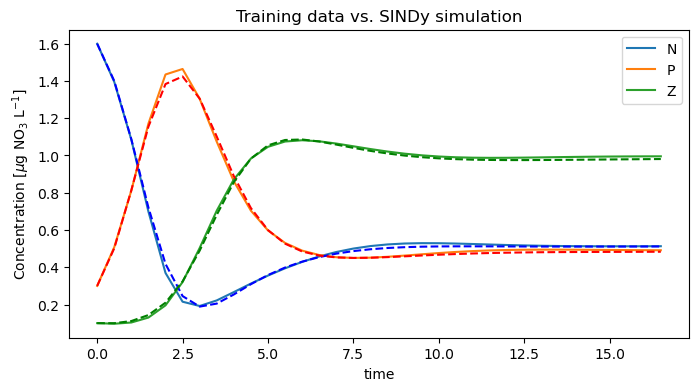

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
train.plot(ax=ax)
ax.plot(train.index, Y[:, 0], 'b--', train.index, Y[:, 1], 'r--', train.index, Y[:, 2], 'g--')
ax.set_ylabel(r"Concentration [$\mu$g NO$_3$ L$^{-1}$]")
ax.set_title("Training data vs. SINDy simulation")

#### State-space comparison

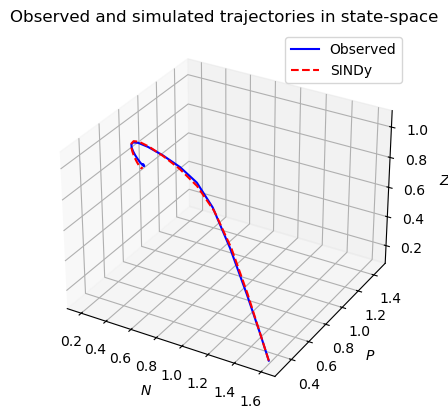

In [11]:
ax = plt.figure().add_subplot(projection='3d')
ax.plot(train['N'], train['P'], train['Z'], 'b', label='Observed')
ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], 'r--', label='SINDy')
ax.set_xlabel('$N$')
ax.set_ylabel('$P$')
ax.set_zlabel('$Z$')
ax.set_title("Observed and simulated trajectories in state-space")
ax.legend()

### Learned equations

In [12]:
model.print()

(x0)' =  0.005 x0 + -0.128 x1 + -0.004 x2 +  0.043 x0^2 + -0.808 x0 x1 +  0.533 x1 x2
(x1)' =  0.353 x0 + -0.226 x2 + -0.243 x0^2 +  0.771 x0 x1 +  0.177 x0 x2 + -0.884 x1 x2 +  0.255 x2^2
(x2)' = -0.167 x0 x2 +  0.699 x1 x2 + -0.256 x2^2


The learned equations can be compared to the known NPZ dynamics.

Key terms to look for:
- interaction terms (e.g., N × P, P × Z)
- linear terms representing growth or mortality

If SINDy is successful, it should recover the dominant interaction structure of the system, even if coefficients are approximate.

### Validation

We next evaluate the learned model on the validation set by simulating forward from the validation initial condition.

In [13]:
X0 = validate[["N", "P", "Z"]].iloc[0].values
Y_val = model.simulate(X0, t=validate.index.values)

rmse_val = np.sqrt(np.mean((validate.values - Y_val)**2))
print(f"Validation RMSE = {rmse_val:.4f} μg L$^{{-1}}$")

Validation RMSE = 0.0135 μg L$^{-1}$


### Test

Finally, we evaluate the learned model on the test set by simulating forward from the test initial condition.

Now that you have a validated model, `simulate` it over the test time-period (starting at the same initial state as `test`).



In [14]:
X0 = test[["N", "P", "Z"]].iloc[0].values
Y_test = model.simulate(X0, t=test.index.values)

rmse_test = np.sqrt(np.mean((test.values - Y_test)**2))
print(f"Test RMSE = {rmse_test:.4f} μg L$^{{-1}}$")

Test RMSE = 0.0135 μg L$^{-1}$
